1. Install and Imports

In [1]:
! pip install mediapipe==0.10.21 opencv-contrib-python==4.10.0.84 numpy==1.26.4 scipy==1.13.1 matplotlib==3.8.4 pandas -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sunil\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import google.protobuf

print("TensorFlow:", tf.__version__)
print("Protobuf:", google.protobuf.__version__)


TensorFlow: 2.15.0
Protobuf: 3.20.3


In [3]:
! pip uninstall -y protobuf
! pip install protobuf==5.29.5

Found existing installation: protobuf 4.25.3
Uninstalling protobuf-4.25.3:
  Successfully uninstalled protobuf-4.25.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 5.29.5 which is incompatible.
tensorflow-intel 2.15.0 requires ml-dtypes~=0.2.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.15.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.29.5 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sunil\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [4]:
import mediapipe as mp

In [5]:
import cv2, numpy as np, math, os, csv, time
import pandas as pd, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from pathlib import Path
from IPython.display import display
print(cv2.__version__, mp.__version__, np.__version__)

4.11.0 0.10.9 1.26.4


 Config

In [6]:
!unzip /content/videos.zip

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [10]:
data  = r'C:\Users\sunil\Downloads\samples\semantic_segmentation\0'


In [11]:
import os
outputDir     = r'C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles'
os.makedirs(outputDir, exist_ok=True)

print(f"Output directory created at: {outputDir}")

Output directory created at: C:\Users\sunil\Downloads\samples\semantic_segmentation\output_angles


In [12]:
datasetRoot   = data

subjectIds    = None
cameraNames   = None
saveVideo     = False

modelComplexity   = 1
minDetectConf     = 0.4
minTrackConf      = 0.4
visibilityThresh  = 0.5
claheClip         = 2.5
claheGrid         = (8, 8)
savgolWindow      = 15
savgolOrder       = 3

os.makedirs(outputDir, exist_ok=True)

root = Path(datasetRoot)
if not root.exists():
    raise FileNotFoundError(f'Dataset root not found: {datasetRoot}')

# Initialize subjectIds and videoFiles for robust population
subjectIds = []
videoFiles = {}

# Check for subdirectories (traditional subject structure)
subdirs = [d for d in root.iterdir() if d.is_dir()]

if subdirs:
    subjectIds = sorted([d.name for d in subdirs])
    for sid in subjectIds:
        subjDir = root / sid
        mp4s = sorted(subjDir.glob('*.mp4'))
        if not mp4s:
            print(f'[WARN] subject {sid}: no .mp4 files found in {subjDir}, skipping')
            continue
        for mp4 in mp4s:
            cam = mp4.stem
            if cameraNames is None or cam in cameraNames:
                videoFiles[(sid, cam)] = str(mp4)
else:
    # No subdirectories, assume videos are directly in datasetRoot and each is a 'subject'
    mp4s_in_root = sorted(root.glob('*.mp4'))
    if not mp4s_in_root:
        print(f'[WARN] No .mp4 files found directly in {root}, skipping all video processing')
    else:
        for mp4 in mp4s_in_root:
            sid = mp4.stem  # Use filename as subject ID
            cam = mp4.stem  # Use filename as camera name
            # Add to subjectIds only if not already present (to avoid duplicates if 'cam' logic changes)
            if sid not in subjectIds:
                subjectIds.append(sid)
            if cameraNames is None or cam in cameraNames:
                videoFiles[(sid, cam)] = str(mp4)
        subjectIds = sorted(list(set(subjectIds))) # Ensure unique and sorted subject IDs


print(f'Subjects: {len(subjectIds)}  |  Videos queued: {len(videoFiles)}')

Subjects: 16  |  Videos queued: 80


Helpers

In [13]:
mpPose = mp.solutions.pose
_clahe = cv2.createCLAHE(clipLimit=claheClip, tileGridSize=claheGrid)

def enhanceFrame(frame):
    l, a, b = cv2.split(cv2.cvtColor(frame, cv2.COLOR_BGR2LAB))
    return cv2.cvtColor(cv2.merge([_clahe.apply(l), a, b]), cv2.COLOR_LAB2BGR)

def angle(a, b, c):
    ba = np.array([a[0]-b[0], a[1]-b[1]], dtype=float)
    bc = np.array([c[0]-b[0], c[1]-b[1]], dtype=float)
    n = np.linalg.norm(ba) * np.linalg.norm(bc)
    return math.degrees(math.acos(np.clip(np.dot(ba,bc)/n,-1,1))) if n else 0.0

def lmPx(lm, idx, w, h):
    p = lm[idx]
    return (int(p.x*w), int(p.y*h)) if p.visibility >= visibilityThresh else None

JOINT_LANDMARKS = {
    'L_hip': 23, 'R_hip': 24,
    'L_knee': 25, 'R_knee': 26,
    'L_ankle': 27, 'R_ankle': 28,
    'L_foot_index': 31, 'R_foot_index': 32,
}
coordFields = [
    f'{name}_{suffix}'
    for name in JOINT_LANDMARKS
    for suffix in ('x_px', 'y_px', 'x_norm', 'y_norm', 'z_norm', 'visibility')
]

def landmarkCoords(lm, idx, w, h):
    p = lm[idx]
    return {
        'x_px': int(round(p.x * w)),
        'y_px': int(round(p.y * h)),
        'x_norm': round(float(p.x), 6),
        'y_norm': round(float(p.y), 6),
        'z_norm': round(float(p.z), 6),
        'visibility': round(float(p.visibility), 3),
    }

def addPoseCoordinates(row, lm, w, h):
    for name, idx in JOINT_LANDMARKS.items():
        for suffix, value in landmarkCoords(lm, idx, w, h).items():
            row[f'{name}_{suffix}'] = value


def drawSkeleton(frame, lm, angles, w, h):
    for s,e in [(23,25),(25,27),(24,26),(26,28),(23,24)]:
        ps,pe = lm[s],lm[e]
        if ps.visibility>=visibilityThresh and pe.visibility>=visibilityThresh:
            cv2.line(frame,(int(ps.x*w),int(ps.y*h)),(int(pe.x*w),int(pe.y*h)),(255,165,0),3,cv2.LINE_AA)
    for i in range(23,33):
        p=lm[i]
        if p.visibility>=visibilityThresh:
            cv2.circle(frame,(int(p.x*w),int(p.y*h)),7,(0,255,0),-1,cv2.LINE_AA)
    for i,lbl,key,col in [(25,'LK','L_knee',(100,255,100)),(26,'RK','R_knee',(100,255,100)),
                           (23,'LH','L_hip',(255,200,100)),(24,'RH','R_hip',(255,200,100)),
                           (27,'LA','L_ankle',(200,100,255)),(28,'RA','R_ankle',(200,100,255))]:
        p=lm[i]; v=angles.get(key)
        if p.visibility>=visibilityThresh and v is not None:
            cv2.putText(frame,f'{lbl}:{v:.0f}',(int(p.x*w)+12,int(p.y*h)-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.55,col,2,cv2.LINE_AA)

csvFields = ['subject','camera','frame','timestampMs','timeS','detection',
             'L_knee','R_knee','L_hip','R_hip','L_ankle','R_ankle',
             'vis_LK','vis_RK','vis_LA','vis_RA','vis_LH','vis_RH'] + coordFields


ANAT_LIMITS = {
    'L_knee':  (0,   175),
    'R_knee':  (0,   175),
    'L_hip':   (-30, 140),
    'R_hip':   (-30, 140),
    'L_ankle': (50,  140),
    'R_ankle': (50,  140),
}

def clip_angle(key, val):
    if val is None:
        return None
    lo, hi = ANAT_LIMITS.get(key, (0, 360))
    return float(np.clip(val, lo, hi))

MAX_INTERP_GAP = 5

def interpolate_with_gap(series, max_gap=MAX_INTERP_GAP):
    s = series.copy().astype(float)
    mask = s.isna()
    if not mask.any():
        return s
    run_id  = mask.ne(mask.shift()).cumsum()
    run_len = mask.groupby(run_id).transform('sum')
    s_interp = s.interpolate(method='linear', limit_direction='both')
    s_interp[mask & (run_len > max_gap)] = float('nan')
    return s_interp

VEL_SPIKE_THRESH = 300   #

def mask_velocity_spikes(series, fps, thresh=VEL_SPIKE_THRESH):
    s   = series.copy().astype(float)
    vel = s.diff().abs() * fps
    s[vel > thresh] = float('nan')
    return s


def cleanNullValues(df, exclude=('subject', 'camera')):
    cleaned = df.copy()
    value_cols = [c for c in cleaned.columns if c not in exclude]
    for col in value_cols:
        cleaned[col] = pd.to_numeric(cleaned[col], errors='coerce')
        if cleaned[col].isna().any():
            cleaned[col] = cleaned[col].interpolate(method='linear', limit_direction='both')
            cleaned[col] = cleaned[col].ffill().bfill()
            cleaned[col] = cleaned[col].fillna(0)
    return cleaned

print('Helpers ready')

Helpers ready


In [14]:
def profileOf(cam):
    c = cam.lower()
    if any(k in c for k in ('left','lft','l_')): return 'left'
    if any(k in c for k in ('right','rgt','r_')): return 'right'
    if any(k in c for k in ('front','fwd','f_','center','ctr')): return 'front'
    return cam

def drawAnglesOnFrame(frame, lm, ang, w, h, profile):
    BONES = [(23,25),(25,27),(24,26),(26,28),(23,24)]
    for s,e in BONES:
        ps,pe = lm[s],lm[e]
        if ps.visibility>=visibilityThresh and pe.visibility>=visibilityThresh:
            cv2.line(frame,(int(ps.x*w),int(ps.y*h)),(int(pe.x*w),int(pe.y*h)),(255,165,0),3,cv2.LINE_AA)
    for i in range(23,33):
        p=lm[i]
        if p.visibility>=visibilityThresh:
            cv2.circle(frame,(int(p.x*w),int(p.y*h)),6,(0,255,120),-1,cv2.LINE_AA)
    joints = [(25,'LK','L_knee',(120,255,120)),(26,'RK','R_knee',(120,255,120)),
              (23,'LH','L_hip',(255,210,80)),(24,'RH','R_hip',(255,210,80)),
              (27,'LA','L_ankle',(180,100,255)),(28,'RA','R_ankle',(180,100,255))]
    for i,lbl,key,col in joints:
        p=lm[i]; v=ang.get(key)
        if p.visibility>=visibilityThresh and v is not None:
            px,py=int(p.x*w),int(p.y*h)
            cv2.putText(frame,f'{lbl}:{v:.0f}deg',(px+10,py-8),
                        cv2.FONT_HERSHEY_SIMPLEX,0.52,col,2,cv2.LINE_AA)
            cv2.circle(frame,(px,py),10,(255,255,0),2,cv2.LINE_AA)
    cv2.putText(frame,f'Profile:{profile}',(10,28),cv2.FONT_HERSHEY_SIMPLEX,0.7,(0,220,255),2,cv2.LINE_AA)
    return frame

print('Profile helpers ready')


Profile helpers ready


 Process All Videos

In [ ]:
allDfs   = []
skipped  = []
total    = len(videoFiles)

with mpPose.Pose(static_image_mode=False, model_complexity=modelComplexity,
                 smooth_landmarks=True, min_detection_confidence=minDetectConf,
                 min_tracking_confidence=minTrackConf) as pose:

    for idx, ((sid, cam), vidPath) in enumerate(videoFiles.items(), 1):
        if not os.path.exists(vidPath):
            print(f'[SKIP {idx:>3}/{total}] subject={sid} {cam}: file not found')
            skipped.append((sid, cam, 'file not found'))
            continue

        cap = cv2.VideoCapture(vidPath)
        if not cap.isOpened():
            print(f'[SKIP {idx:>3}/{total}] subject={sid} {cam}: cannot open video')
            skipped.append((sid, cam, 'cannot open'))
            continue

        fpsVid  = cap.get(cv2.CAP_PROP_FPS) or 30.0
        _sw_raw = max(savgolOrder + 2, round(savgolWindow / 30.0 * fpsVid))
        swLocal = _sw_raw if _sw_raw % 2 == 1 else _sw_raw + 1
        totalF  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        vidW    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        vidH    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        subjOut = os.path.join(outputDir, f'subject_{sid}')
        os.makedirs(subjOut, exist_ok=True)

        writer = None
        if saveVideo:
            writer = cv2.VideoWriter(os.path.join(subjOut, f'{cam}_annotated.mp4'),
                                     cv2.VideoWriter_fourcc(*'mp4v'), 30, (vidW, vidH))

        rows, detected, frameIdx, t0 = [], 0, 0, time.time()

        while True:
            ok, frame = cap.read()
            if not ok: break
            frameIdx += 1
            h, w = frame.shape[:2]

            rgb = cv2.cvtColor(enhanceFrame(frame), cv2.COLOR_BGR2RGB)
            rgb.flags.writeable = False
            res = pose.process(rgb)

            row = {'subject':sid,'camera':cam,'frame':frameIdx,
                   'timestampMs':round(frameIdx/fpsVid*1000,1),
                   'timeS':round(frameIdx/fpsVid,4),
                   'detection':0,
                   'L_knee':None,'R_knee':None,'L_hip':None,'R_hip':None,
                   'L_ankle':None,'R_ankle':None,
                   'vis_LK':None,'vis_RK':None,'vis_LA':None,
                   'vis_RA':None,'vis_LH':None,'vis_RH':None}
            row.update({field: None for field in coordFields})

            if res.pose_landmarks:
                detected += 1
                lm = res.pose_landmarks.landmark
                row.update({'detection':1,
                            'vis_LK':round(lm[25].visibility,3),'vis_RK':round(lm[26].visibility,3),
                            'vis_LA':round(lm[27].visibility,3),'vis_RA':round(lm[28].visibility,3),
                            'vis_LH':round(lm[23].visibility,3),'vis_RH':round(lm[24].visibility,3)})
                addPoseCoordinates(row, lm, w, h)

                LH=lmPx(lm,23,w,h);RH=lmPx(lm,24,w,h);LK=lmPx(lm,25,w,h)
                RK=lmPx(lm,26,w,h);LA=lmPx(lm,27,w,h);RA=lmPx(lm,28,w,h)
                LFI=lmPx(lm,31,w,h);RFI=lmPx(lm,32,w,h)

                ang = {}
                if all([LH,LK,LA]):  ang['L_knee']  = row['L_knee']  = round(clip_angle('L_knee', angle(LH,LK,LA)), 2)
                if all([RH,RK,RA]):  ang['R_knee']  = row['R_knee']  = round(clip_angle('R_knee', angle(RH,RK,RA)), 2)
                # Hip flexion vs. downward vertical
                _vt = np.array([0.0, 1.0])
                if LH and LK:
                    thigh_L = np.array([LK[0]-LH[0], LK[1]-LH[1]], dtype=float)
                    n_L = np.linalg.norm(thigh_L)
                    if n_L > 0:
                        hip_L = math.degrees(math.acos(np.clip(np.dot(thigh_L/n_L, _vt), -1, 1)))
                        ang['L_hip'] = row['L_hip'] = round(clip_angle('L_hip', hip_L), 2)
                if RH and RK:
                    thigh_R = np.array([RK[0]-RH[0], RK[1]-RH[1]], dtype=float)
                    n_R = np.linalg.norm(thigh_R)
                    if n_R > 0:
                        hip_R = math.degrees(math.acos(np.clip(np.dot(thigh_R/n_R, _vt), -1, 1)))
                        ang['R_hip'] = row['R_hip'] = round(clip_angle('R_hip', hip_R), 2)
                if all([LK,LA,LFI]): ang['L_ankle'] = row['L_ankle'] = round(clip_angle('L_ankle', angle(LK,LA,LFI)), 2)
                if all([RK,RA,RFI]): ang['R_ankle'] = row['R_ankle'] = round(clip_angle('R_ankle', angle(RK,RA,RFI)), 2)

                if writer: drawSkeleton(frame, lm, ang, w, h)

            if writer: writer.write(frame)
            rows.append(row)

        cap.release()
        if writer: writer.release()

        if frameIdx == 0:
            print(f'[WARN {idx:>3}/{total}] subject={sid} {cam}: 0 frames read')
            skipped.append((sid, cam, '0 frames read'))
            continue

        dfCam = pd.DataFrame(rows, columns=csvFields)
        for _ac in ['L_knee','R_knee','L_hip','R_hip','L_ankle','R_ankle']:
            dfCam[_ac] = mask_velocity_spikes(dfCam[_ac], fpsVid)
            dfCam[_ac] = interpolate_with_gap(dfCam[_ac])
        dfCam = cleanNullValues(dfCam)
        dfCam.to_csv(os.path.join(subjOut, f'{cam}_angles.csv'), index=False)
        allDfs.append(dfCam)

        print(f'[{idx:>3}/{total}] s={sid} {cam}  {frameIdx}fr  '
              f'det={100*detected/frameIdx:.0f}%  {time.time()-t0:.1f}s')

if allDfs:
    merged = cleanNullValues(pd.concat(allDfs, ignore_index=True))
    merged.to_csv(os.path.join(outputDir,'ALL_subjects_angles.csv'), index=False)
    print(f'\nMerged CSV: {len(merged)} rows | null values: {int(merged.isna().sum().sum())}')

if skipped:
    print(f'\nSkipped ({len(skipped)}):')
    for s in skipped: print(f'  subject={s[0]} {s[1]}: {s[2]}')

print('Done.')

Sample Frames

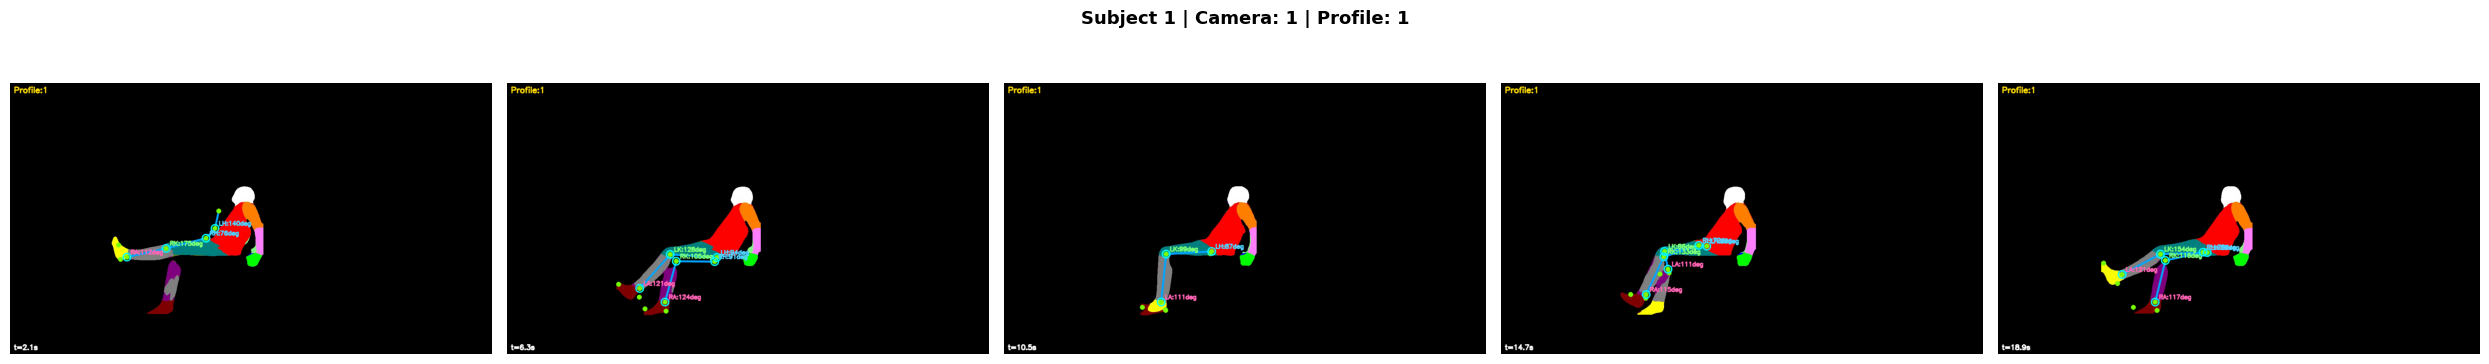

Saved: /content/output/subject_1/frames_1.png


In [ ]:
sidQa   = subjectIds[0]
camsQa  = [(s,c) for (s,c) in videoFiles if s == sidQa]
SAMPLE_POINTS = [0.1, 0.3, 0.5, 0.7, 0.9]

with mpPose.Pose(static_image_mode=True, model_complexity=modelComplexity,
                 min_detection_confidence=minDetectConf) as poseS:
    for sid, cam in camsQa:
        profile = profileOf(cam)
        cap     = cv2.VideoCapture(videoFiles[(sid,cam)])
        nf      = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frames  = []
        for frac in SAMPLE_POINTS:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(nf*frac))
            ok, frm = cap.read()
            if not ok: continue
            h,w = frm.shape[:2]
            res = poseS.process(cv2.cvtColor(enhanceFrame(frm), cv2.COLOR_BGR2RGB))
            ang = {}
            if res.pose_landmarks:
                lm = res.pose_landmarks.landmark
                def _p(i): p=lm[i]; return (int(p.x*w),int(p.y*h)) if p.visibility>=visibilityThresh else None
                LH,RH,LK,RK,LA,RA=_p(23),_p(24),_p(25),_p(26),_p(27),_p(28)
                LFI,RFI=_p(31),_p(32)
                if all([LH,LK,LA]):  ang['L_knee']=clip_angle('L_knee',angle(LH,LK,LA))
                if all([RH,RK,RA]):  ang['R_knee']=clip_angle('R_knee',angle(RH,RK,RA))
                if LH and LK:
                    th=np.array([LK[0]-LH[0],LK[1]-LH[1]],dtype=float); n=np.linalg.norm(th)
                    if n>0: ang['L_hip']=clip_angle('L_hip',math.degrees(math.acos(np.clip(np.dot(th/n,[0,1]),-1,1))))
                if RH and RK:
                    th=np.array([RK[0]-RH[0],RK[1]-RH[1]],dtype=float); n=np.linalg.norm(th)
                    if n>0: ang['R_hip']=clip_angle('R_hip',math.degrees(math.acos(np.clip(np.dot(th/n,[0,1]),-1,1))))
                if all([LK,LA,LFI]): ang['L_ankle']=clip_angle('L_ankle',angle(LK,LA,LFI))
                if all([RK,RA,RFI]): ang['R_ankle']=clip_angle('R_ankle',angle(RK,RA,RFI))
                drawAnglesOnFrame(frm, lm, ang, w, h, profile)
            ts = round(nf*frac/cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) else 0, 1)
            cv2.putText(frm,f't={ts}s',(10,h-12),cv2.FONT_HERSHEY_SIMPLEX,0.6,(255,255,255),2,cv2.LINE_AA)
            frames.append(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
        cap.release()
        if not frames: continue
        n  = len(frames)
        fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
        if n==1: axes=[axes]
        fig.suptitle(f'Subject {sid} | Camera: {cam} | Profile: {profile}', fontsize=13, fontweight='bold')
        for ax, img in zip(axes, frames):
            ax.imshow(img); ax.axis('off')
        plt.tight_layout()
        out = os.path.join(outputDir, f'subject_{sid}', f'frames_{cam}.png')
        plt.savefig(out, dpi=110, bbox_inches='tight')
        plt.show()
        print(f'Saved: {out}')


TimeSeries

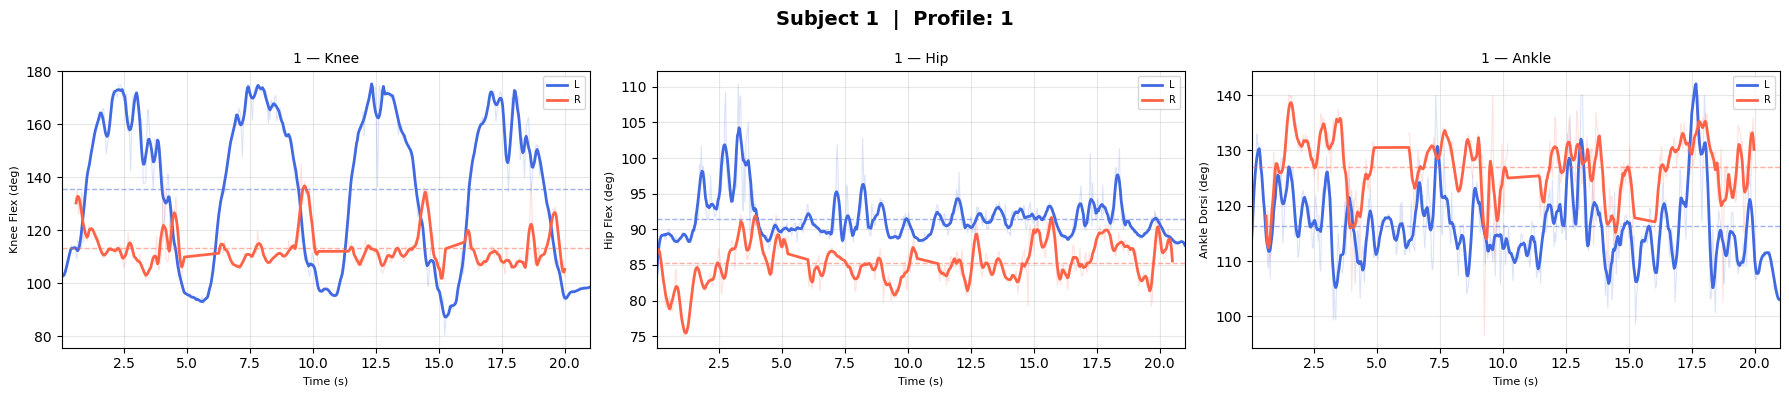

Saved: /content/output/ts_1_1.png


In [ ]:
sidPlot  = subjectIds[0]
dfsSubj  = [df for df in allDfs if df['subject'].iloc[0] == sidPlot]
aPairs   = [('L_knee','R_knee','Knee Flex (deg)'),
             ('L_hip','R_hip','Hip Flex (deg)'),
             ('L_ankle','R_ankle','Ankle Dorsi (deg)')]

profileGroups = {}
for df in dfsSubj:
    p = profileOf(df['camera'].iloc[0])
    profileGroups.setdefault(p, []).append(df)

for profile, dfs in profileGroups.items():
    nC = len(dfs)
    fig, axes = plt.subplots(nC, 3, figsize=(18, 4*nC))
    if nC==1: axes=[axes]
    fig.suptitle(f'Subject {sidPlot}  |  Profile: {profile}', fontsize=14, fontweight='bold')
    for ri, df in enumerate(dfs):
        t = df['timeS']
        for ci, (lc,rc,yl) in enumerate(aPairs):
            ax = axes[ri][ci]
            fps_df  = 1.0 / df['timeS'].diff().median() if df['timeS'].diff().median() > 0 else 30.0
            _sw_r   = max(savgolOrder+2, round(savgolWindow/30.0*fps_df))
            sw_plot = _sw_r if _sw_r%2==1 else _sw_r+1
            lr = interpolate_with_gap(df[lc]); rr = interpolate_with_gap(df[rc])
            ls = savgol_filter(lr.dropna(),sw_plot,savgolOrder) if lr.notna().sum()>=sw_plot else lr.dropna().values
            rs = savgol_filter(rr.dropna(),sw_plot,savgolOrder) if rr.notna().sum()>=sw_plot else rr.dropna().values
            t_l = df.loc[lr.notna(),'timeS']; t_r = df.loc[rr.notna(),'timeS']
            ax.plot(df['timeS'],lr,alpha=0.18,color='royalblue',lw=0.8)
            ax.plot(df['timeS'],rr,alpha=0.18,color='tomato',lw=0.8)
            ax.plot(t_l,ls,color='royalblue',lw=2,label='L')
            ax.plot(t_r,rs,color='tomato',lw=2,label='R')
            if len(ls): ax.axhline(ls.mean(),color='royalblue',lw=1,ls='--',alpha=0.5)
            if len(rs): ax.axhline(rs.mean(),color='tomato',lw=1,ls='--',alpha=0.5)
            ax.set_title(f"{df['camera'].iloc[0]} — {yl.split(' ')[0]}",fontsize=10)
            ax.set_xlabel('Time (s)',fontsize=8); ax.set_ylabel(yl,fontsize=8)
            ax.legend(fontsize=7); ax.grid(True,alpha=0.3); ax.set_xlim(t.min(),t.max())
    plt.tight_layout()
    out = os.path.join(outputDir, f'ts_{sidPlot}_{profile}.png')
    plt.savefig(out, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')


Frame Strip w Angles Overlay

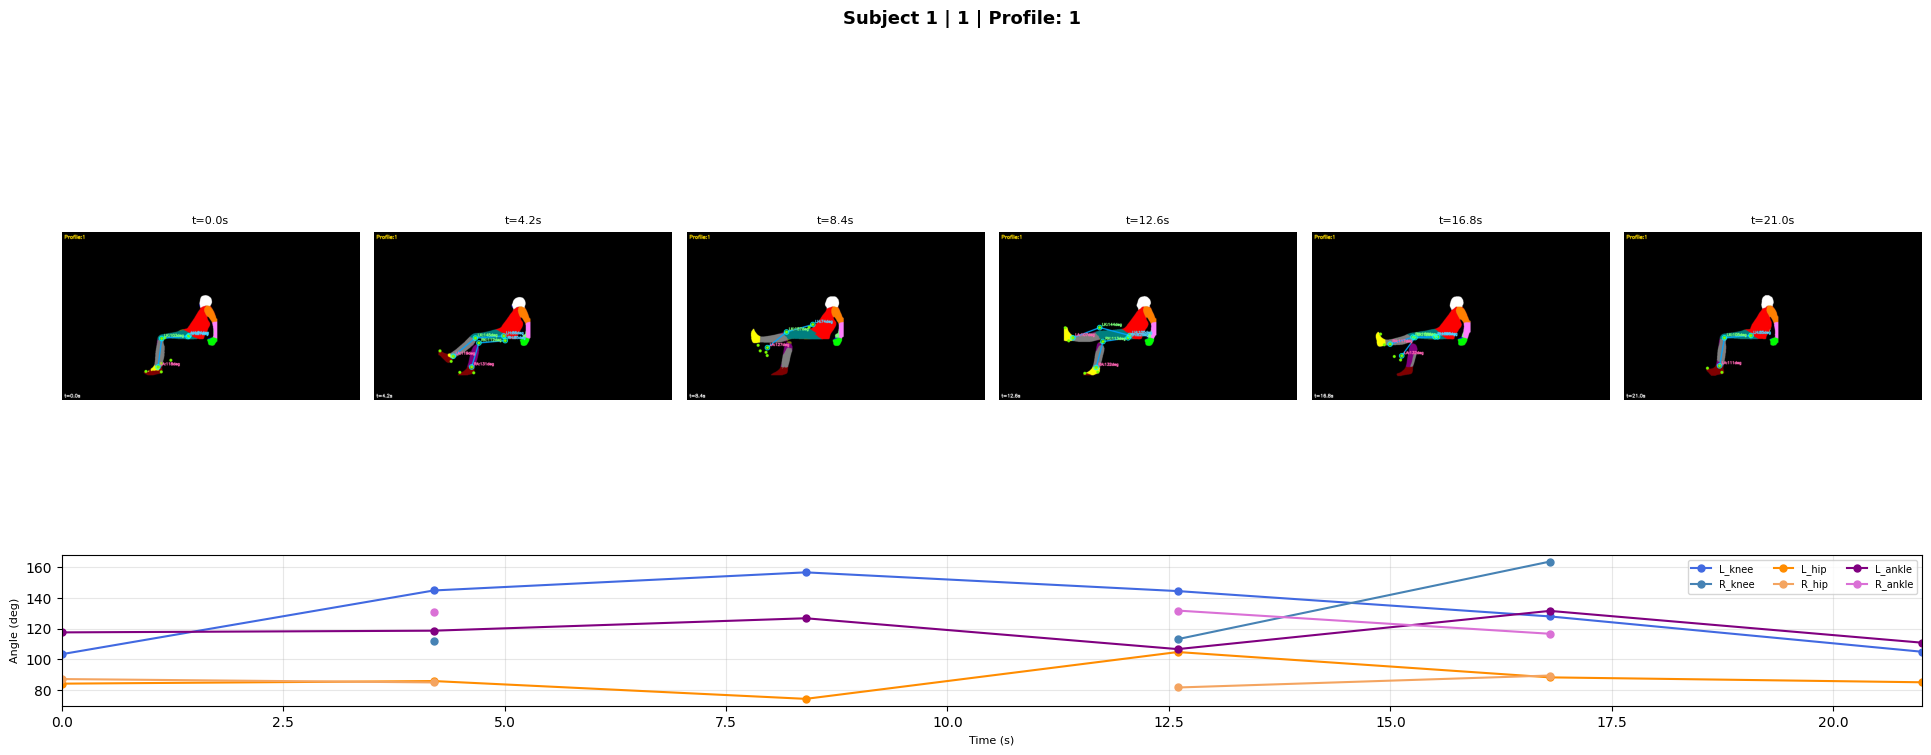

Saved: /content/output/subject_1/frame_angles_1.png


In [ ]:
sidViz = subjectIds[0]
STRIP_FRAMES = 6

with mpPose.Pose(static_image_mode=True, model_complexity=modelComplexity,
                 min_detection_confidence=minDetectConf) as poseS:
    for df in [d for d in allDfs if d['subject'].iloc[0] == sidViz]:
        cam     = df['camera'].iloc[0]
        profile = profileOf(cam)
        vidPath = videoFiles.get((sidViz, cam))
        if not vidPath: continue
        cap = cv2.VideoCapture(vidPath)
        nf  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

        strip_imgs, strip_ts, strip_angs = [], [], {}
        for k in ['L_knee','R_knee','L_hip','R_hip','L_ankle','R_ankle']:
            strip_angs[k] = []

        for fi in [int(nf*i/(STRIP_FRAMES-1)) for i in range(STRIP_FRAMES)]:
            cap.set(cv2.CAP_PROP_POS_FRAMES, min(fi, nf-1))
            ok, frm = cap.read()
            if not ok: continue
            h,w = frm.shape[:2]
            res = poseS.process(cv2.cvtColor(enhanceFrame(frm), cv2.COLOR_BGR2RGB))
            ang = {k: None for k in strip_angs}
            if res.pose_landmarks:
                lm = res.pose_landmarks.landmark
                def _p(i): p=lm[i]; return (int(p.x*w),int(p.y*h)) if p.visibility>=visibilityThresh else None
                LH,RH,LK,RK,LA,RA=_p(23),_p(24),_p(25),_p(26),_p(27),_p(28)
                LFI,RFI=_p(31),_p(32)
                if all([LH,LK,LA]):  ang['L_knee']=round(clip_angle('L_knee',angle(LH,LK,LA)),1)
                if all([RH,RK,RA]):  ang['R_knee']=round(clip_angle('R_knee',angle(RH,RK,RA)),1)
                if LH and LK:
                    th=np.array([LK[0]-LH[0],LK[1]-LH[1]],dtype=float); n=np.linalg.norm(th)
                    if n>0: ang['L_hip']=round(clip_angle('L_hip',math.degrees(math.acos(np.clip(np.dot(th/n,[0,1]),-1,1)))),1)
                if RH and RK:
                    th=np.array([RK[0]-RH[0],RK[1]-RH[1]],dtype=float); n=np.linalg.norm(th)
                    if n>0: ang['R_hip']=round(clip_angle('R_hip',math.degrees(math.acos(np.clip(np.dot(th/n,[0,1]),-1,1)))),1)
                if all([LK,LA,LFI]): ang['L_ankle']=round(clip_angle('L_ankle',angle(LK,LA,LFI)),1)
                if all([RK,RA,RFI]): ang['R_ankle']=round(clip_angle('R_ankle',angle(RK,RA,RFI)),1)
                drawAnglesOnFrame(frm, lm, ang, w, h, profile)
            for k in strip_angs: strip_angs[k].append(ang[k])
            ts_val = round(fi/fps, 2)
            cv2.putText(frm,f't={ts_val}s',(10,h-12),cv2.FONT_HERSHEY_SIMPLEX,0.65,(255,255,255),2)
            strip_imgs.append(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
            strip_ts.append(ts_val)
        cap.release()
        if not strip_imgs: continue

        n = len(strip_imgs)
        fig = plt.figure(figsize=(4*n, 8))
        gs  = fig.add_gridspec(2, n, height_ratios=[3,1], hspace=0.04, wspace=0.05)
        fig.suptitle(f'Subject {sidViz} | {cam} | Profile: {profile}', fontsize=13, fontweight='bold')

        for i, img in enumerate(strip_imgs):
            ax = fig.add_subplot(gs[0, i])
            ax.imshow(img); ax.axis('off')
            ax.set_title(f't={strip_ts[i]}s', fontsize=8)

        axB = fig.add_subplot(gs[1, :])
        colors = {'L_knee':'royalblue','R_knee':'steelblue',
                  'L_hip':'darkorange','R_hip':'sandybrown',
                  'L_ankle':'purple','R_ankle':'orchid'}
        for k, col in colors.items():
            vals = [v if v is not None else float('nan') for v in strip_angs[k]]
            axB.plot(strip_ts, vals, 'o-', color=col, lw=1.5, ms=5, label=k)
        axB.set_xlabel('Time (s)', fontsize=8); axB.set_ylabel('Angle (deg)', fontsize=8)
        axB.legend(ncol=3, fontsize=7, loc='upper right'); axB.grid(True, alpha=0.3)
        axB.set_xlim(strip_ts[0], strip_ts[-1])

        out = os.path.join(outputDir, f'subject_{sidViz}', f'frame_angles_{cam}.png')
        plt.savefig(out, dpi=120, bbox_inches='tight')
        plt.show()
        print(f'Saved: {out}')


ROM

In [ ]:
aCols = ['L_knee','R_knee','L_hip','R_hip','L_ankle','R_ankle']
DET_FLAG_WARN  = 0.50
DET_FLAG_POOR  = 0.30

rows  = []
for df in allDfs:
    det_rate = df['detection'].mean()
    if det_rate >= DET_FLAG_WARN:
        det_flag = 'ok'
    elif det_rate >= DET_FLAG_POOR:
        det_flag = 'low'
    else:
        det_flag = 'poor'
    r = {'subject':df['subject'].iloc[0],'camera':df['camera'].iloc[0],
         'det_%':f"{100*det_rate:.1f}",'det_flag':det_flag,'frames':len(df)}
    for c in aCols:
        s = df[c].dropna()
        n_valid = len(s)
        if n_valid == 0:
            r[f'{c}_mean'] = 'N/A'
            r[f'{c}_ROM']  = 'N/A'
            r[f'{c}_n']    = 0
        else:
            w = det_rate if det_flag != 'poor' else float('nan')
            r[f'{c}_mean']   = f'{s.mean():.1f}'
            r[f'{c}_ROM']    = f'{s.max()-s.min():.1f}'
            r[f'{c}_n']      = n_valid
            r[f'{c}_wtmean'] = f'{s.mean()*w:.1f}' if not isinstance(w, float) or not __import__("math").isnan(w) else 'unreliable'
    rows.append(r)
dfSummary = pd.DataFrame(rows)
dfSummary.to_csv(os.path.join(outputDir,'rom_summary.csv'), index=False)
display(dfSummary.head(20))

,subject,camera,det_%,det_flag,frames,L_knee_mean,L_knee_ROM,L_knee_n,L_knee_wtmean,R_knee_mean,...,R_hip_n,R_hip_wtmean,L_ankle_mean,L_ankle_ROM,L_ankle_n,L_ankle_wtmean,R_ankle_mean,R_ankle_ROM,R_ankle_n,R_ankle_wtmean
0,1,1,100.0,ok,630,135.8,94.6,630,135.8,113.3,...,568,85.3,116.4,41.5,630,116.4,127.1,43.4,483,127.1
1,10,10,100.0,ok,916,133.4,95.6,916,133.4,N/A,...,8,94.6,106.1,61.8,892,106.1,N/A,N/A,0,NaN
2,11,11,94.7,ok,794,155.3,157.9,744,147.1,164.3,...,182,98.7,110.7,46.0,744,104.8,116.6,38.7,181,110.4
3,12,12,100.0,ok,794,156.3,35.8,781,156.3,159.5,...,741,91.6,114.1,39.0,794,114.1,114.8,47.2,694,114.8
4,13,13,100.0,ok,794,157.0,35.3,794,157.0,160.4,...,574,95.3,111.3,29.4,794,111.3,112.0,32.4,574,112.0
5,14,14,100.0,ok,794,159.8,39.4,794,159.8,159.3,...,581,95.1,122.3,35.3,794,122.3,127.3,30.9,581,127.3
6,15,15,100.0,ok,794,156.8,42.9,794,156.8,160.1,...,719,96.6,110.3,45.6,794,110.3,103.2,40.8,719,103.2
7,16,16,99.9,ok,1146,109.4,102.3,1146,109.3,84.6,...,40,129.2,129.2,37.6,1146,129.1,135.5,20.6,38,135.4
8,17,17,100.0,ok,1146,111.6,109.1,1146,111.6,154.5,...,722,95.0,129.0,31.1,1146,129.0,130.1,45.5,722,130.1
9,18,18,100.0,ok,1146,112.6,103.2,1146,112.6,138.0,...,201,105.7,126.6,40.3,1146,126.6,133.8,27.7,201,133.8


In [ ]:
import os

# Display the path to the merged CSV file
merged_csv_path = os.path.join(outputDir, 'ALL_subjects_angles.csv')
print(f"Merged time series angles + coordinates data saved to: {merged_csv_path}")

# Display the first 5 rows of the merged DataFrame
print(f"Null values remaining: {int(merged.isna().sum().sum())}")
print("\nFirst 5 rows of the merged time series data:")
display(merged.head())

Merged time series data saved to: /content/output/ALL_subjects_angles.csv

First 5 rows of the merged time series data:


,subject,camera,frame,timestampMs,timeS,detection,L_knee,R_knee,L_hip,R_hip,L_ankle,R_ankle,vis_LK,vis_RK,vis_LA,vis_RA,vis_LH,vis_RH
0,1,1,1,33.3,0.0333,1,103.33,NaN,84.14,87.14,117.54,NaN,0.995,0.549,0.992,0.433,1.0,0.999
1,1,1,2,66.7,0.0667,1,102.21,NaN,85.20,87.22,116.80,NaN,0.994,0.548,0.991,0.435,1.0,0.999
2,1,1,3,100.0,0.1000,1,103.34,NaN,86.12,85.56,115.28,NaN,0.994,0.547,0.986,0.431,1.0,0.998
3,1,1,4,133.3,0.1333,1,103.59,NaN,88.57,86.60,121.99,NaN,0.993,0.553,0.982,0.437,1.0,0.998
4,1,1,5,166.7,0.1667,1,105.11,NaN,89.05,87.14,127.35,NaN,0.992,0.556,0.980,0.441,1.0,0.998


In [ ]:
summary_csv_path = os.path.join(outputDir, 'rom_summary.csv')
print(f"ROM summary data saved to: {summary_csv_path}")

print("\nFirst 5 rows of the ROM summary data:")
display(dfSummary.head())

ROM summary data saved to: /content/output/rom_summary.csv

First 5 rows of the ROM summary data:


,subject,camera,det_%,det_flag,frames,L_knee_mean,L_knee_ROM,L_knee_n,L_knee_wtmean,R_knee_mean,...,R_hip_n,R_hip_wtmean,L_ankle_mean,L_ankle_ROM,L_ankle_n,L_ankle_wtmean,R_ankle_mean,R_ankle_ROM,R_ankle_n,R_ankle_wtmean
0,1,1,100.0,ok,630,135.8,94.6,630,135.8,113.3,...,568,85.3,116.4,41.5,630,116.4,127.1,43.4,483,127.1
1,10,10,100.0,ok,916,133.4,95.6,916,133.4,N/A,...,8,94.6,106.1,61.8,892,106.1,N/A,N/A,0,NaN
2,11,11,94.7,ok,794,155.3,157.9,744,147.1,164.3,...,182,98.7,110.7,46.0,744,104.8,116.6,38.7,181,110.4
3,12,12,100.0,ok,794,156.3,35.8,781,156.3,159.5,...,741,91.6,114.1,39.0,794,114.1,114.8,47.2,694,114.8
4,13,13,100.0,ok,794,157.0,35.3,794,157.0,160.4,...,574,95.3,111.3,29.4,794,111.3,112.0,32.4,574,112.0


In [ ]:
import cv2
import pandas as pd
import os

merged_df = pd.read_csv(os.path.join(outputDir, 'ALL_subjects_angles.csv'))

print("\nVerifying Frame Counts in CSV vs. Original Videos")

all_frames_match = True
for (sid, cam), vidPath in videoFiles.items():
    # Count frames in the original video file
    cap = cv2.VideoCapture(vidPath)
    if not cap.isOpened():
        print(f"[ERROR] Could not open video file: {vidPath}")
        all_frames_match = False
        continue
    original_frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    # Count frames for this (subject, camera) pair in the merged DataFrame
    csv_frame_count = len(merged_df[(merged_df['subject'] == int(sid)) & (merged_df['camera'] == int(cam))])

    if original_frame_count == csv_frame_count:
        print(f"Subject {sid}, Camera {cam}: Original frames = {original_frame_count}, CSV rows = {csv_frame_count} (MATCH)")
    else:
        print(f"Subject {sid}, Camera {cam}: Original frames = {original_frame_count}, CSV rows = {csv_frame_count} (MISMATCH!)")
        all_frames_match = False

if all_frames_match:
    print("\nVERIFICATION COMPLETE: All original video frames successfully match the rows in the ALL_subjects_angles.csv file.")
else:
    print("\nVERIFICATION COMPLETE: Some videos show a mismatch in frame count. Please check the warnings above.")


Verifying Frame Counts in CSV vs. Original Videos
Subject 1, Camera 1: Original frames = 630, CSV rows = 630 (MATCH)
Subject 10, Camera 10: Original frames = 916, CSV rows = 916 (MATCH)
Subject 11, Camera 11: Original frames = 794, CSV rows = 794 (MATCH)
Subject 12, Camera 12: Original frames = 794, CSV rows = 794 (MATCH)
Subject 13, Camera 13: Original frames = 794, CSV rows = 794 (MATCH)
Subject 14, Camera 14: Original frames = 794, CSV rows = 794 (MATCH)
Subject 15, Camera 15: Original frames = 794, CSV rows = 794 (MATCH)
Subject 16, Camera 16: Original frames = 1146, CSV rows = 1146 (MATCH)
Subject 17, Camera 17: Original frames = 1146, CSV rows = 1146 (MATCH)
Subject 18, Camera 18: Original frames = 1146, CSV rows = 1146 (MATCH)
Subject 19, Camera 19: Original frames = 1146, CSV rows = 1146 (MATCH)
Subject 2, Camera 2: Original frames = 630, CSV rows = 630 (MATCH)
Subject 20, Camera 20: Original frames = 1146, CSV rows = 1146 (MATCH)
Subject 21, Camera 21: Original frames = 687, 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>